In [1]:
import spacy
import spacy_transformers

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

LOAD THE MODELS AND DATASET

In [3]:
nlp1 = spacy.load('en_core_web_sm')
nlp2 = spacy.load('en_core_web_md')
nlp3 = spacy.load('en_core_web_lg')
nlp4 = spacy.load('en_core_web_trf')

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\thinc\shims\pytorch.py:261: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues r

In [ ]:
text="Rohit Sharma Barred From Travelling To Pakistan, Fresh Feud Triggers Between BCCI And PCB: Report. Rohit Sharma was to travel to Pakistan for pre-Champions Trophy press conference and a customary photoshoot but the BCCI barred the Indian captain from doing so. Rohit Sharma Barred From Travelling To Pakistan, Fresh Feud Triggers Between BCCI And PCB. A fresh Controversy has triggered ahead of the start of the ICC Champions Trophy, with the Board of Control for Cricket in India (BCCI) and the Pakistan Cricket Board (PCB) coming at loggerheads again. The BCCI, after refusing to send its team to Pakistan for Champions Trophy participation, managed to convert the tournament into a hybrid mode, with India playing their matches in Dubai. Now, the Indian board has barred captain Rohit Sharma from travelling to Pakistan for two curtain-raiser events - the captains press conference and the customary photoshoot. As per a report in the Times of India, the BCCI has asked ICC to shift both pre-tournament events to Dubai so that skipper Rohit can be physically present to participate in the events. The move from the BCCI has understandably left the Pakistan board infuriated. ICC has already accommodated India's request not to schedule its Champions Trophy matches in Pakistan, so these are minor issues, the paper quoted a source as saying. Another issue that has been doing rounds in the internet is the BCCI's reluctance to have 'Pakistan' written on Team India's kits. While ICC's rule states that the name of the hosting country has to be a part of the logo on the participating teams shirts, the Indian board wants an exception as the team would be playing its matches in Dubai."

About the dataset
- small talk
- consists of short phrases 5-6 words per sentence

In [4]:
with open(r"C:\Users\Dell\Desktop\Krignal\Small_talk_Intent.csv", "r") as file:
    text = file.read()

In [5]:
text=text.replace("\n",". ")

In [ ]:
text

,uuid,publisher,heading,published_date,content,url,name
0,cb248e6f-8a8c-4202-b4a0-1e6a8c655ef7,1e9abc28-20ab-4126-97ab-c5a79776b2a6,Nvidia Unveils Latest Chips at ‘AI Woodstock’,NaT,NaN,https://www.wsj.com/tech/ai/nvidia-annual-conf...,wall_street_journal
1,fac17cdf-8b98-453a-8bd2-b25f7e503cd9,f1712561-9be1-474f-ad22-0fad473fb690,"Freed Americans land in the U.S., reunite with...",NaT,NaN,https://www.nbcnews.com/video/freed-americans-...,nbc_news
2,0968b595-71ff-4b4a-8183-677c758b9e7d,f1712561-9be1-474f-ad22-0fad473fb690,How the Russian prisoner swap that freed Evan ...,NaT,NaN,https://www.nbcnews.com/news/world/russian-pri...,nbc_news
3,1d5d94c2-70ab-4f30-b314-701781823942,f1712561-9be1-474f-ad22-0fad473fb690,U.S. voters targeted by Chinese influence onli...,NaT,NaN,https://www.nbcnews.com/tech/internet/us-voter...,nbc_news
4,d8c831d8-de94-41ab-8be5-f00686337073,d58be1b2-848b-42b7-bd42-a9f7c9c58ccf,My father signed over all his properties to my...,NaT,NaN,https://www.marketwatch.com/story/my-stepmothe...,market_watch
...,...,...,...,...,...,...,...
22593,4a58d289-08db-4d5b-bbb8-96e9b0e9f12e,1277d4db-c9ad-483f-8b41-5f3bda8e3e38,DealStreetAsia - Asia-focused financial news a...,2021-05-04 02:12:04,Venture Capital\nThe AI-focused fund was launc...,https://www.dealstreetasia.com/countries/vietnam,dealstreet_asia
22594,b4c6055a-96ae-4801-a334-1e9b5aef7bd9,1277d4db-c9ad-483f-8b41-5f3bda8e3e38,DealStreetAsia - Asia-focused financial news a...,2021-05-04 02:12:04,Deals\nDigital health platform Alodokter recei...,https://www.dealstreetasia.com/countries/malaysia,dealstreet_asia
22595,0772db3a-f584-4610-a8b9-ca4dda4f16c2,1277d4db-c9ad-483f-8b41-5f3bda8e3e38,DealStreetAsia - Asia-focused financial news a...,2021-05-04 02:12:04,Deals\nThis edition features earnings analysis...,https://www.dealstreetasia.com/countries/singa...,dealstreet_asia
22596,422b39c5-1c1e-4aa9-b26c-208f69b3ad4a,1277d4db-c9ad-483f-8b41-5f3bda8e3e38,DealStreetAsia - Asia-focused financial news a...,2021-05-04 02:12:04,Deals\nThis edition features earnings analysis...,https://www.dealstreetasia.com/countries/indon...,dealstreet_asia


GENERAL DIFFERENCES

In [9]:
models = [nlp1, nlp2, nlp3, nlp4] 

In [10]:
for i, model in enumerate(models):
    doc = model(text)
    entity_types = [(entity.text, entity.label_) for entity in doc.ents]
    print(f"Model {i+1} Entities: {entity_types}")

ValueError: [E1041] Expected a string, Doc, or bytes as input, but got: <class 'pandas.core.frame.DataFrame'>

METRICS FOR NAMED ENTITY RECOGNITION

In [29]:
ground_truth = [('Sebastian Thrun', 'PERSON'), ('Google', 'ORG'), ('2007', 'DATE'), ('American', 'NORP'), ('Thrun', 'PERSON'), ('Recode', 'ORG'), ('earlier this week', 'DATE')]

for i, model in enumerate(models):
    doc = model("When Sebastian Thrun started working on self-driving cars at Google in 2007, few people outside of the company took him seriously."
                "I can tell you very senior CEOs of major American"
                " car companies would shake my hand and turn away because I wasnt "
                "worth talking to said Thrun, in an interview with Recode earlier "
                "this week.")
    entity_types = [(entity.text, entity.label_) for entity in doc.ents]
    #print(f"Model {i+1} Entities: {entity_types}")
    model_entities = [(entity.text, entity.label_) for entity in doc.ents]

    correct = set(model_entities).intersection(set(ground_truth))
    precision = len(correct) / len(model_entities) if model_entities else 0
    recall = len(correct) / len(ground_truth)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    print(f"Model {i+1} - Precision: {precision:.2f}, Recall: {recall:.2f}, F1-score: {f1:.2f}")

Model 1 - Precision: 1.00, Recall: 1.00, F1-score: 1.00
Model 2 - Precision: 0.86, Recall: 0.86, F1-score: 0.86
Model 3 - Precision: 0.83, Recall: 0.71, F1-score: 0.77
Model 4 - Precision: 1.00, Recall: 1.00, F1-score: 1.00


In [ ]:
models = [nlp1, nlp2, nlp3, nlp4]  
model_names = ["Model 1", "Model 2", "Model 3", "Model 4"]
ground_truth = [(5, 20, "PERSON"), (38, 43, "ORG"),(60, 65, "PERSON"), (88,94,"ORG"), (95, 112, "DATE")] 

entity_heatmap = np.zeros((len(models), len(text))) 
text = "When Sebastian Thrun started working, tesla talking to said Thrun, in an interview with Recode earlier this week."

for i, model in enumerate(models):
    doc = model(text)
    for entity in doc.ents:
        start, end = entity.start_char, entity.end_char
        entity_heatmap[i, start:end] = 1  

entity_heatmap_with_gt = np.vstack([entity_heatmap, np.zeros(len(text))])
for start, end, label in ground_truth:
    entity_heatmap_with_gt[-1, start:end] = 1

model_names_with_gt = model_names + ["Ground Truth"]
plt.figure(figsize=(15, 8))
sns.heatmap(
    entity_heatmap_with_gt,
    cmap="Blues",
    cbar=True,
    xticklabels=list(text),
    yticklabels=model_names_with_gt
)
plt.title("Heatmap with Ground Truth Comparison", fontsize=16)
plt.xlabel("Character Position in Text", fontsize=12)
plt.ylabel("Models", fontsize=12)
plt.show()

DEPENDENCY PARSER

In [14]:
olist = []
for i, model in enumerate(models):
    doc = model(text)
    for chunk in doc.noun_chunks:
        olist.append([i+1,chunk.text, chunk.label_, chunk.root.text])
odf = pd.DataFrame(olist)
odf.columns = ["Model number","NounPhrase", "Label", "RootWord"]
odf

,Model number,NounPhrase,Label,RootWord
0,1,Utterances,NP,Utterances
1,1,who,NP,who
2,1,you,NP,you
3,1,you,NP,you
4,1,what,NP,what
...,...,...,...,...
13193,4,i,NP,i
13194,4,a couple,NP,couple
13195,4,minutes,NP,minutes
13196,4,i,NP,i


TOKENIZATION ACCURACY

In [ ]:
# Ground truth tokens (manually segmented or pre-determined)
ground_truth_tokens = [
    "Rohit", "Sharma", "Barred", "From", "Travelling", "To", "Pakistan", ",",
    "Fresh", "Feud", "Triggers", "Between", "BCCI", "And", "PCB", ":", "Report", ".",
    "Rohit", "Sharma", "was", "to", "travel", "to", "Pakistan", "for", "pre-Champions",
    "Trophy", "press", "conference", "and", "a", "customary", "photoshoot", "but", "the",
    "BCCI", "barred", "the", "Indian", "captain", "from", "doing", "so", ".",
]
text="Rohit Sharma Barred From Travelling To Pakistan, Fresh Feud Triggers Between BCCI And PCB: Report. Rohit Sharma was to travel to Pakistan for pre-Champions Trophy press conference and a customary photoshoot but the BCCI barred the Indian captain from doing so."

models = [nlp1, nlp2, nlp3, nlp4]

for i, model in enumerate(models):
    # Tokenize the text using the model
    doc = model(" ".join(ground_truth_tokens))  # Full input text
    model_tokens = [token.text for token in doc]  # Extract tokens

    # Compare with ground truth
    correct = set(model_tokens).intersection(set(ground_truth_tokens))
    accuracy = len(correct) / len(ground_truth_tokens) if len(ground_truth_tokens) > 0 else 0

    print(f"Model {i+1} Tokenization Accuracy: {accuracy:.2f}")

#this also doesnt seem accurate because all models have a tokenization accuracy of 1 on the website

Model 1 Tokenization Accuracy: 0.82
Model 2 Tokenization Accuracy: 0.82
Model 3 Tokenization Accuracy: 0.82
Model 4 Tokenization Accuracy: 0.82


METRICS FOR SENTENCE SEGMENTATION

In [ ]:
from nltk.tokenize import sent_tokenize  

ground_truth=[
    "Rohit Sharma Barred From Travelling To Pakistan, Fresh Feud Triggers Between BCCI And PCB: Report",
    "Rohit Sharma was to travel to Pakistan for pre-Champions Trophy press conference and a customary photoshoot but the BCCI barred the Indian captain from doing so.",
    "Rohit Sharma Barred From Travelling To Pakistan, Fresh Feud Triggers Between BCCI And PCB. A fresh Controversy has triggered ahead of the start of the ICC Champions Trophy, with the Board of Control for Cricket in India (BCCI) and the Pakistan Cricket Board (PCB) coming at loggerheads again",
    "The BCCI, after refusing to send its team to Pakistan for Champions Trophy participation, managed to convert the tournament into a hybrid mode, with India playing their matches in Dubai.",
    "Now, the Indian board has barred captain Rohit Sharma from travelling to Pakistan for two curtain-raiser events - the captains press conference and the customary photoshoot.",
    "As per a report in the Times of India, the BCCI has asked ICC to shift both pre-tournament events to Dubai so that skipper Rohit can be physically present to participate in the events",
    "The move from the BCCI has understandably left the Pakistan board infuriated. ICC has already accommodated India's request not to schedule its Champions Trophy matches in Pakistan, so these are minor issues, the paper quoted a source as saying. Another issue that has been doing rounds in the internet is the BCCI's reluctance to have 'Pakistan' written on Team India's kits",
    "While ICC's rule states that the name of the hosting country has to be a part of the logo on the participating teams shirts, the Indian board wants an exception as the team would be playing its matches in Dubai"
]

models = [nlp1, nlp2, nlp3, nlp4]

for i, model in enumerate(models):
    doc = model(" ".join(ground_truth))  
    model_sentences = [sent.text for sent in doc.sents]  
    correct = set(model_sentences).intersection(set(ground_truth))
    accuracy = len(correct) / len(ground_truth) if len(ground_truth) > 0 else 0

    print(f"Model {i+1} Sentence Segmentation Accuracy: {accuracy:.2f}")
#should be higher

Model 1 Sentence Segmentation Accuracy: 0.12
Model 2 Sentence Segmentation Accuracy: 0.12
Model 3 Sentence Segmentation Accuracy: 0.12
Model 4 Sentence Segmentation Accuracy: 0.62


PARTS OF SPEECH

In [ ]:
ground_truth = [
    ("Rohit", "PROPN"), ("Sharma", "PROPN"), ("Barred", "VERB"), ("From", "ADP"),
    ("Travelling", "VERB"), ("To", "ADP"), ("Pakistan", "PROPN"), (",", "PUNCT"),
    ("Fresh", "ADJ"), ("Feud", "NOUN"), ("Triggers", "VERB"), ("Between", "ADP"),
    ("BCCI", "PROPN"), ("And", "CCONJ"), ("PCB", "PROPN"), (":", "PUNCT"),
    ("Report", "NOUN"), (".", "PUNCT"),
]
text="Rohit Sharma Barred From Travelling To Pakistan, Fresh Feud Triggers Between BCCI And PCB: Report."

accuracies = []
for i, model in enumerate(models):
    doc = model(text)
    predicted_tags = [(token.text, token.pos_) for token in doc]  # Predicted word and POS tags
    
    correct = 0
    total = len(ground_truth)
    
    for (pred_word, pred_tag), (true_word, true_tag) in zip(predicted_tags, ground_truth):
        if pred_word == true_word and pred_tag == true_tag:
            correct += 1

    accuracy = correct / total
    accuracies.append(accuracy)
    print(f"Model {i+1} POS Accuracy: {accuracy:.2f}")

Model 1 POS Accuracy: 0.78
Model 2 POS Accuracy: 0.72
Model 3 POS Accuracy: 0.83
Model 4 POS Accuracy: 0.94


In [ ]:
plt.bar([f"Model {i+1}" for i in range(len(models))], accuracies, color="skyblue")
plt.title("POS Tagging Accuracy Across Models")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

TIME DIFFERENCE

In [15]:
import time
t=[]

for i, model in enumerate(models):
    start_time = time.time()
    doc = model(text)
    end_time = time.time() 
    inference_time = end_time - start_time  # Calculate time taken
    t.append([f"Model {i+1}", inference_time])  
    print(f"Model {i+1} Inference Time: {end_time - start_time:.4f} seconds")

Model 1 Inference Time: 1.9338 seconds
Model 2 Inference Time: 1.6200 seconds
Model 3 Inference Time: 1.7333 seconds
Model 4 Inference Time: 19.6027 seconds


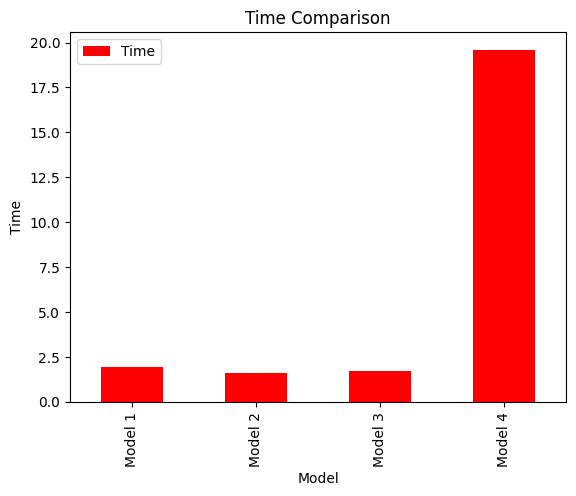

In [16]:
df = pd.DataFrame(t, columns=["Model", "Time"])
df.plot(x="Model", y="Time", kind="bar", color="red")
plt.title("Time Comparison")
plt.ylabel("Time")
plt.show()

COUNT OF ENTITIIES

In [32]:
results = []

for i, model in enumerate(models):
    doc = model(text)
    entity_count = len(doc.ents)
    results.append((f"Model {i+1}", entity_count))

print("Entity Counts per Model:", results)

Entity Counts per Model: [('Model 1', 99), ('Model 2', 128), ('Model 3', 79), ('Model 4', 124)]


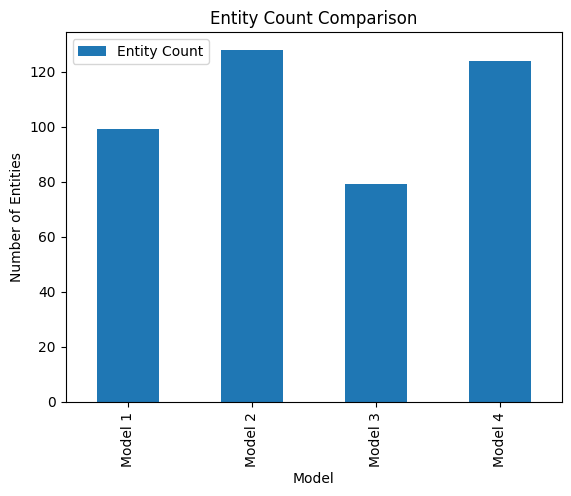

In [33]:
df = pd.DataFrame(results, columns=["Model", "Entity Count"])
df.plot(x="Model", y="Entity Count", kind="bar")
plt.title("Entity Count Comparison")
plt.ylabel("Number of Entities")
plt.show()

COUNT OF UNIQUE ENTITIES

In [34]:
all_entities = []
l=[]
for i, model in enumerate(models):
    doc = model(text)
    all_entities.append(set([(entity.text, entity.label_) for entity in doc.ents]))

common_entities = set.intersection(*all_entities)
unique_entities = [entities - common_entities for entities in all_entities]

print("Common Entities:", len(common_entities))
for i, unique in enumerate(unique_entities):
    l.append((f"Model {i+1}:", len(unique)))
    print(f"Unique Entities in Model {i+1}:", len(unique))

Common Entities: 19
Unique Entities in Model 1: 19
Unique Entities in Model 2: 35
Unique Entities in Model 3: 12
Unique Entities in Model 4: 18


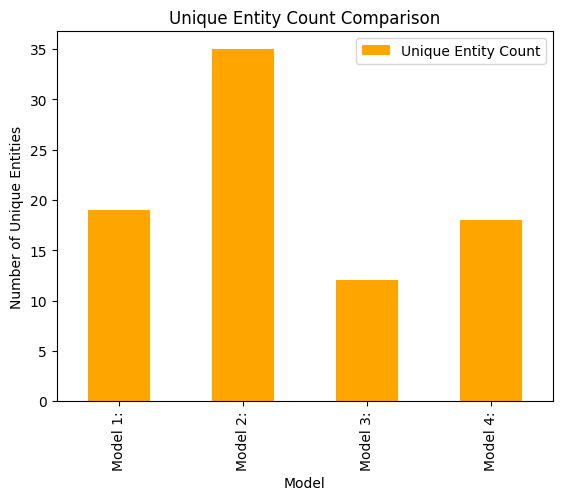

In [35]:
df1 = pd.DataFrame(l, columns=["Model", "Unique Entity Count"])
df1.plot(x="Model", y="Unique Entity Count", kind="bar", color="orange")
plt.title("Unique Entity Count Comparison")
plt.ylabel("Number of Unique Entities")
plt.show()

HEAT MAP OF DETCTED ENTITIES

In [36]:
#text = "When Sebastian Thrun started working, tesla talking to said Thrun, in an interview with Recode earlier this week."

models = [nlp1, nlp2, nlp3, nlp4]  # Replace with actual SpaCy models
model_names = ["Model 1", "Model 2", "Model 3", "Model 4"]

# Create a matrix to track entity coverage
entity_heatmap = np.zeros((len(models), len(text)))  

for i, model in enumerate(models):
    doc = model(text)
    for entity in doc.ents:
        start, end = entity.start_char, entity.end_char
        entity_heatmap[i, start:end] = 1  

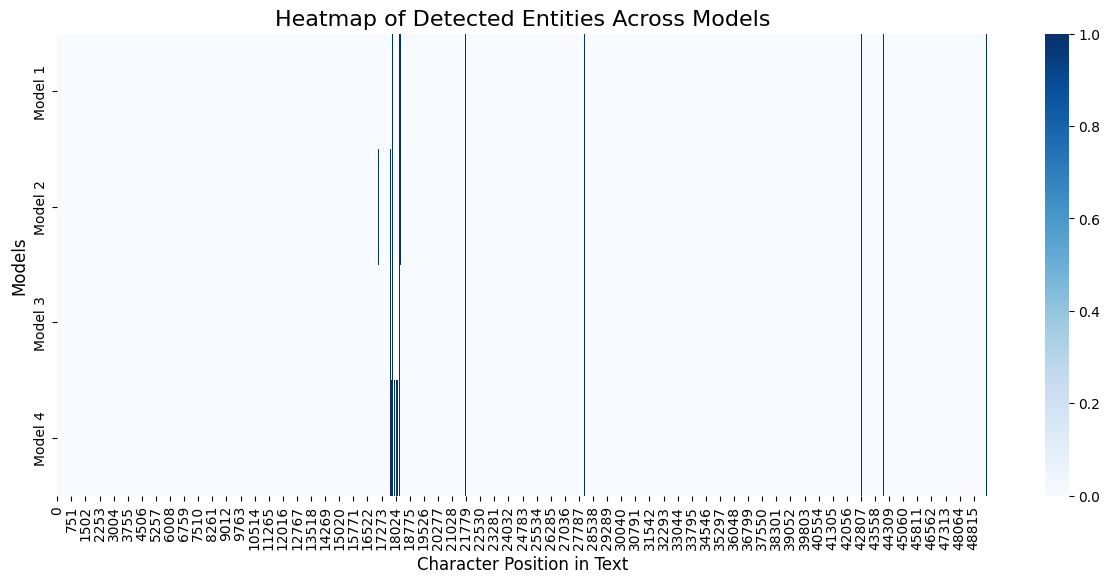

In [37]:
# Plot heatmap using seaborn
plt.figure(figsize=(15, 6))
sns.heatmap(
    entity_heatmap,
    #cmap="YlGnBu",
    cmap="Blues",
    cbar=True, 
    yticklabels=model_names  # Display model names on the y-axis
)

# Add labels and title
plt.title("Heatmap of Detected Entities Across Models", fontsize=16)
plt.xlabel("Character Position in Text", fontsize=12)
plt.ylabel("Models", fontsize=12)
plt.show()

TO COMPARE HOW EACH MODEL WORKS WITH SPECIFIC ENTITIES

In [ ]:
entity_type = "ORG"  # Change to any type you want to visualize
entity_type_heatmap = np.zeros((len(models), len(text)))

for i, model in enumerate(models):
    doc = model(text)
    for entity in doc.ents:
        if entity.label_ == entity_type:
            start, end = entity.start_char, entity.end_char
            entity_type_heatmap[i, start:end] = 1

plt.figure(figsize=(15, 6))
sns.heatmap(
    entity_type_heatmap,
    cmap="Blues",
    cbar=True,
    xticklabels=list(text),
    yticklabels=model_names
)
plt.title(f"Heatmap for '{entity_type}' Entities Across Models", fontsize=16)
plt.xlabel("Character Position in Text", fontsize=12)
plt.ylabel("Models", fontsize=12)
plt.show()

In [23]:
text

"Utterances who are you? all about you what is your personality define yourself what are you say about you introduce yourself describe yourself about yourself tell me about you tell me about yourself I want to know more about you I want to know you better talk some stuff about yourself tell me some stuff about you talk about yourself why are you here tell me about your personality who are you how old are you? how old is your platform are you 21 years old i'd like to know your age age of yours your age what's your age tell me your age how old are you you're annoying you are really annoying you are irritating you annoy me how annoying you are I find you annoying you're incredibly annoying you are annoying me so much I want you to answer me answer answer my question answer me give me an answer answer the question can you answer my question tell me the answer answer it give me the answer I have a question I want you to answer my question just answer the question can you answer me answers c

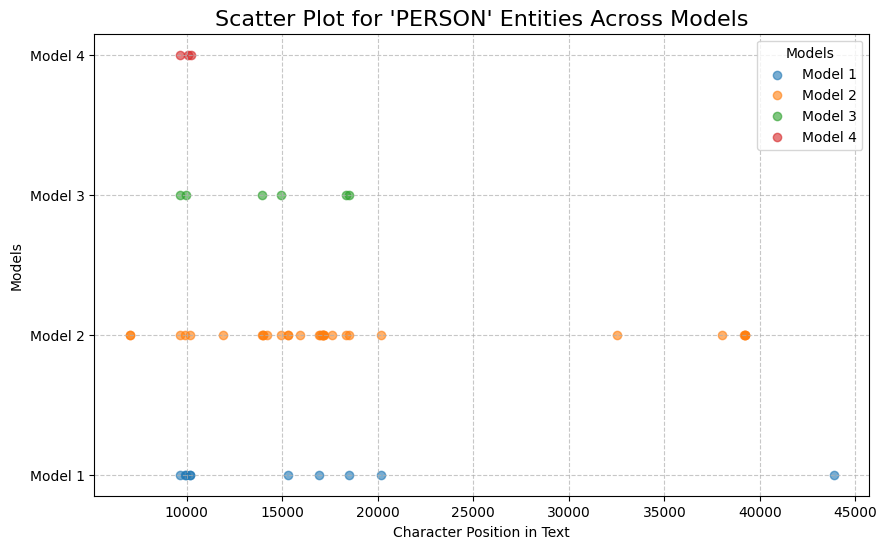

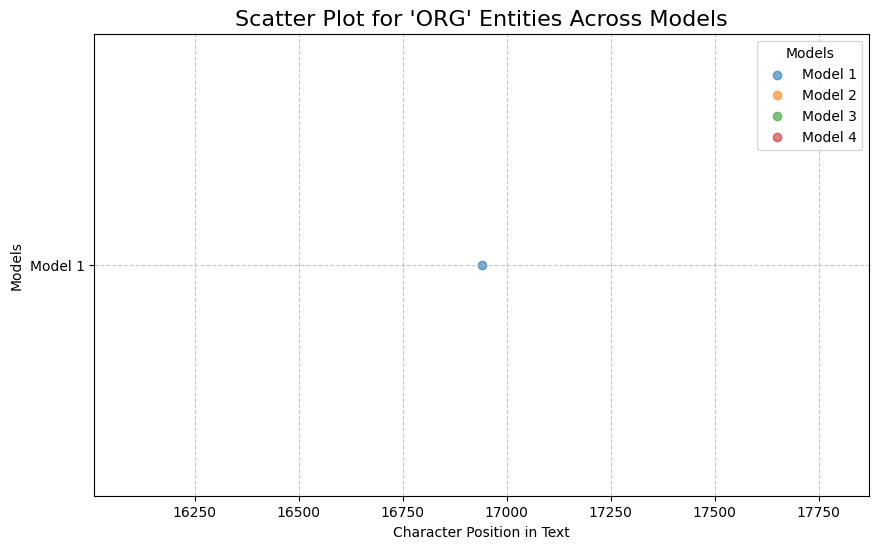

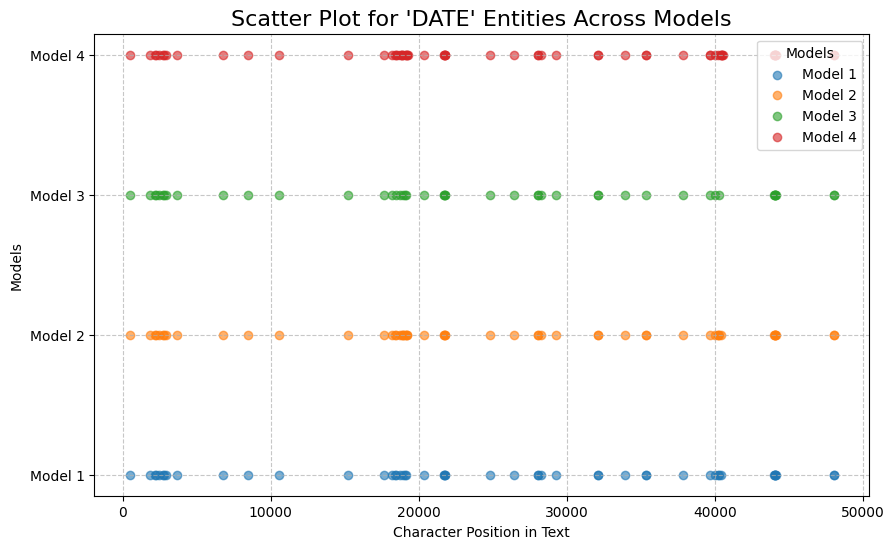

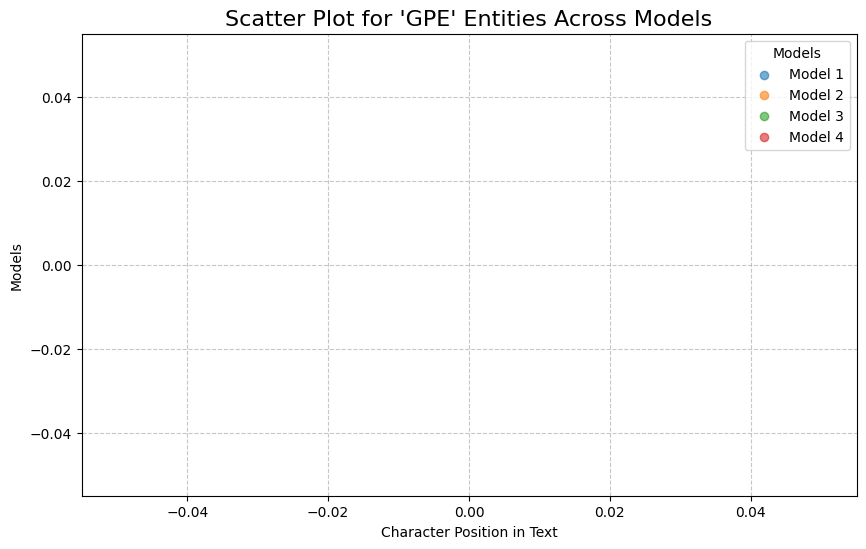

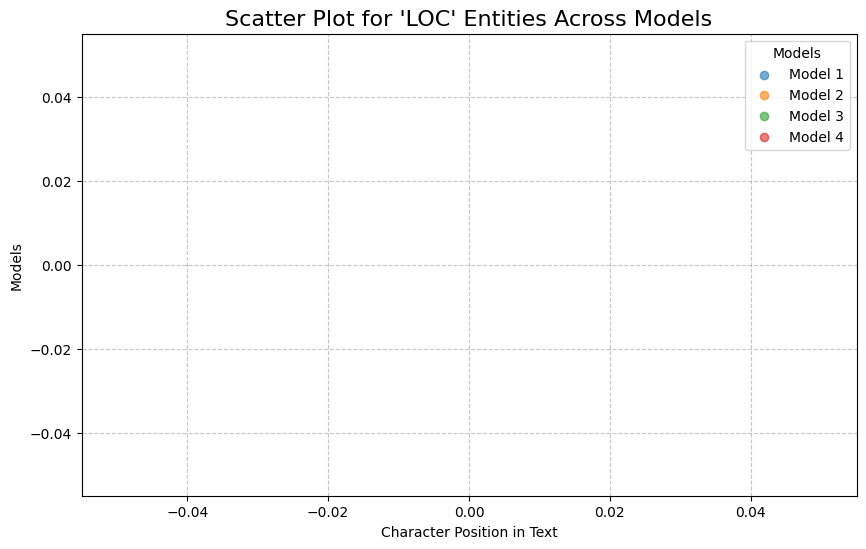

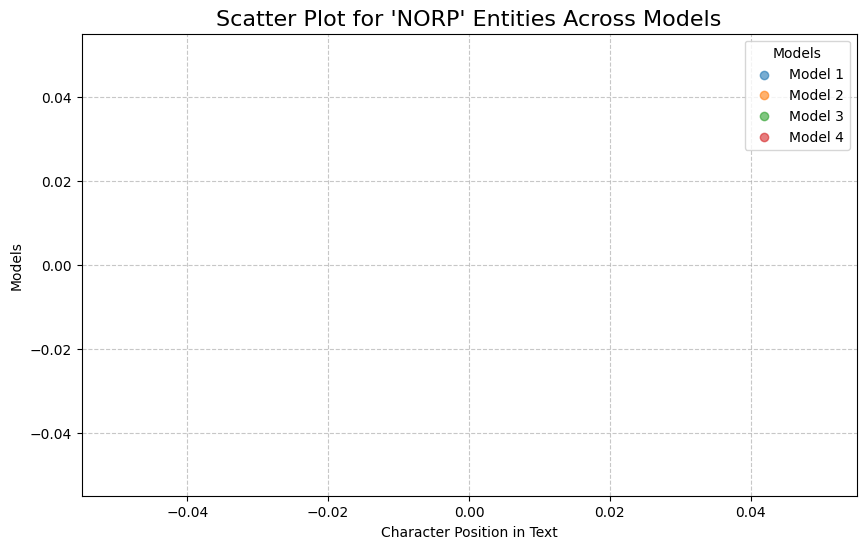

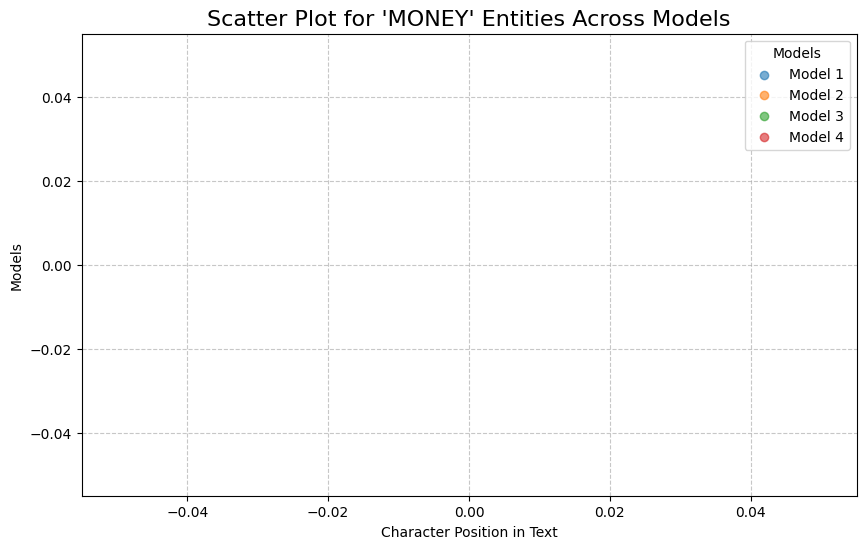

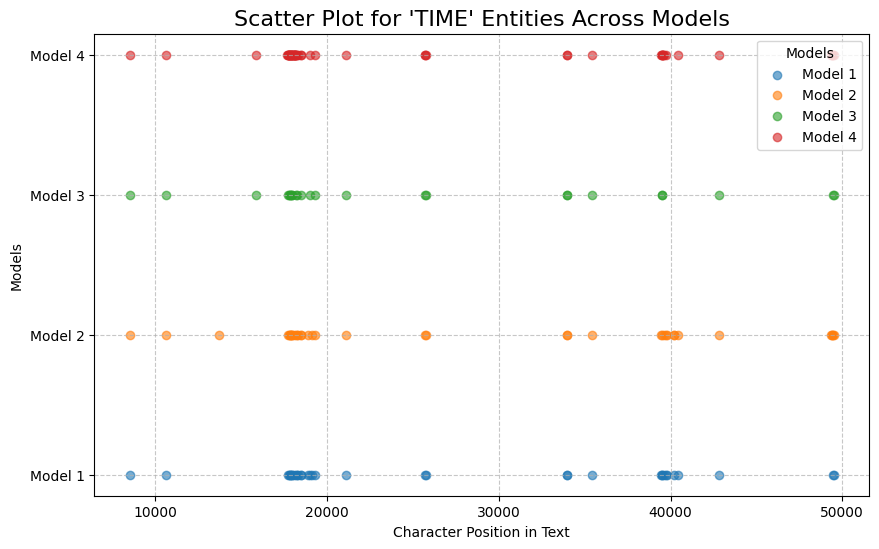

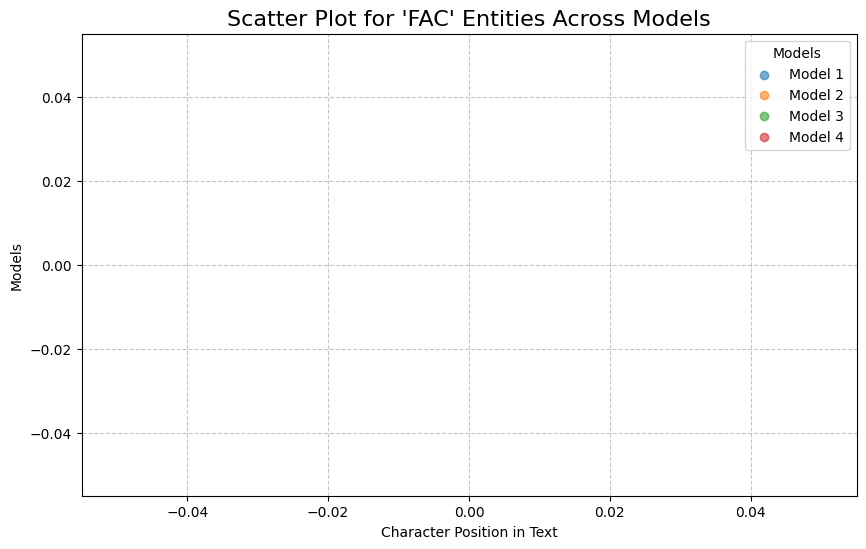

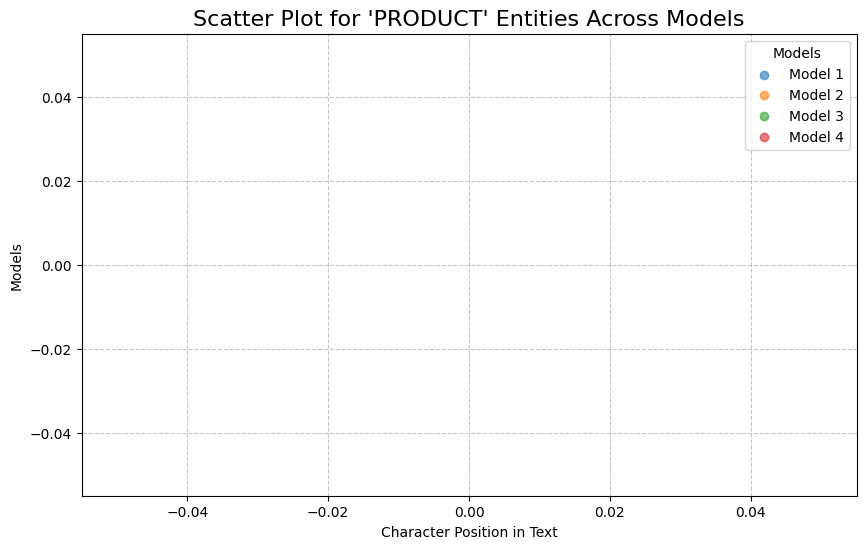

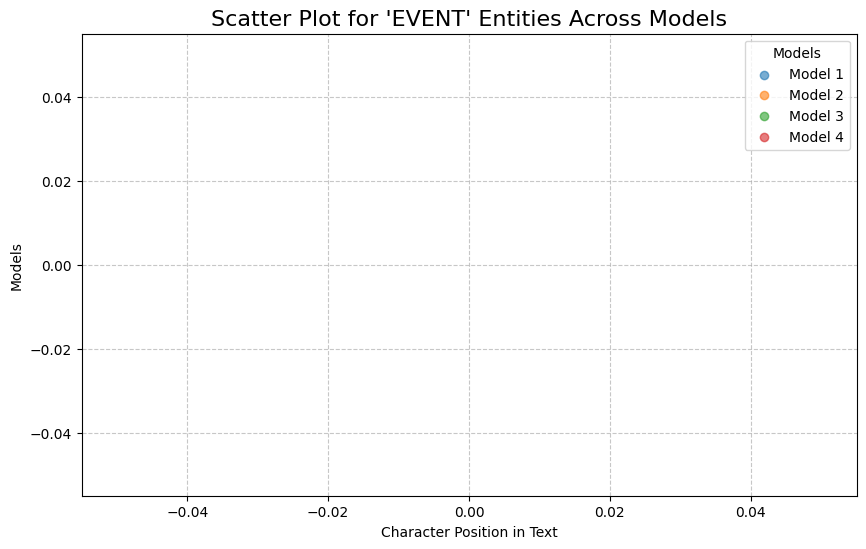

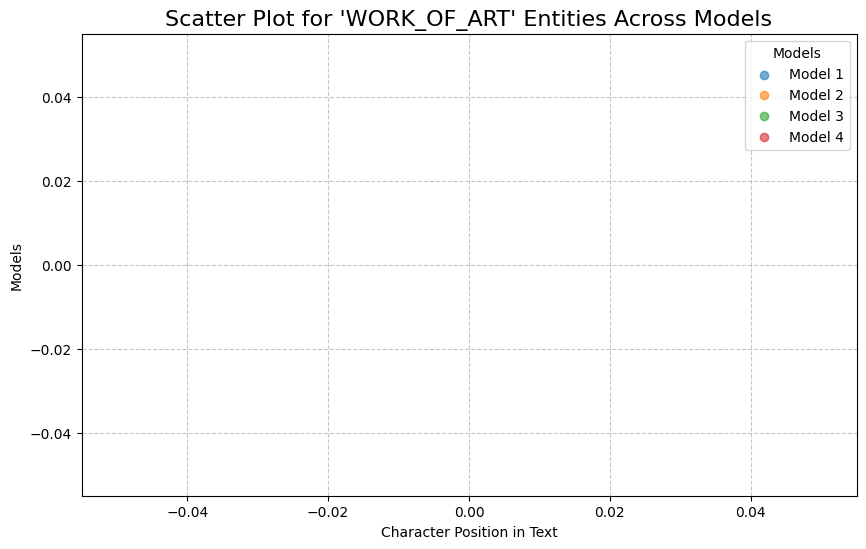

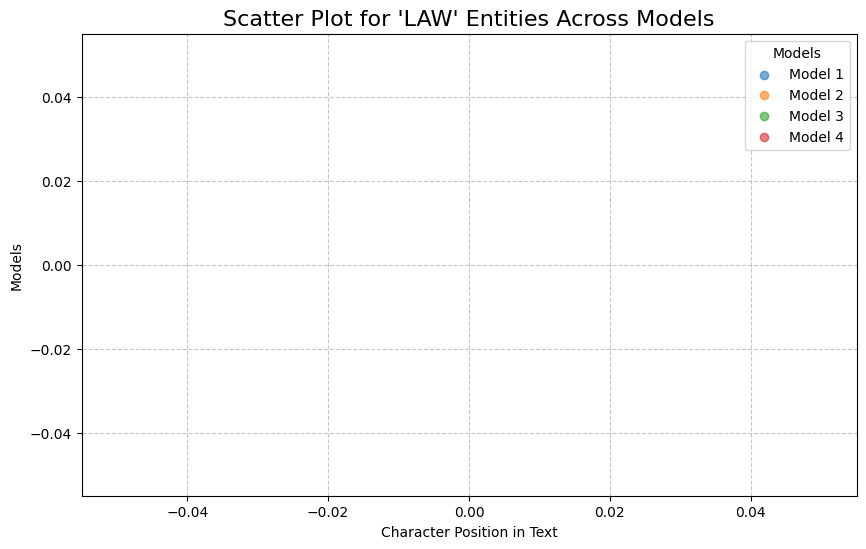

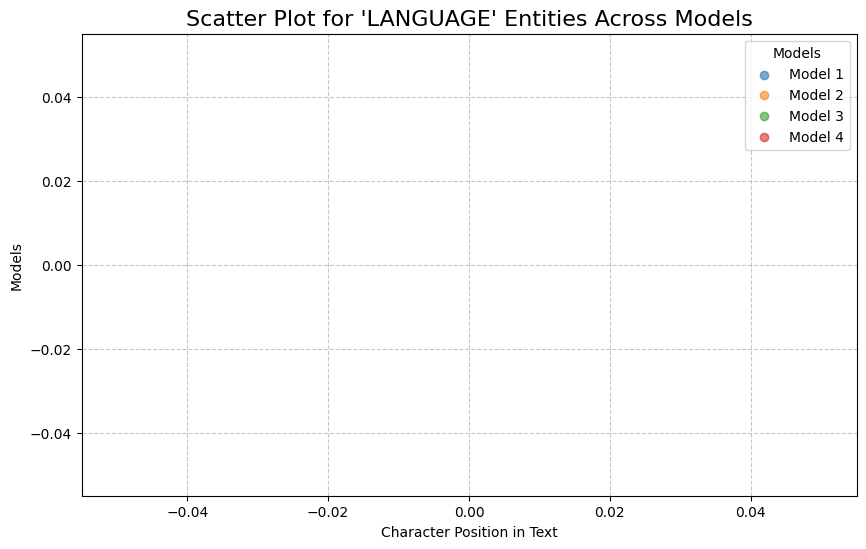

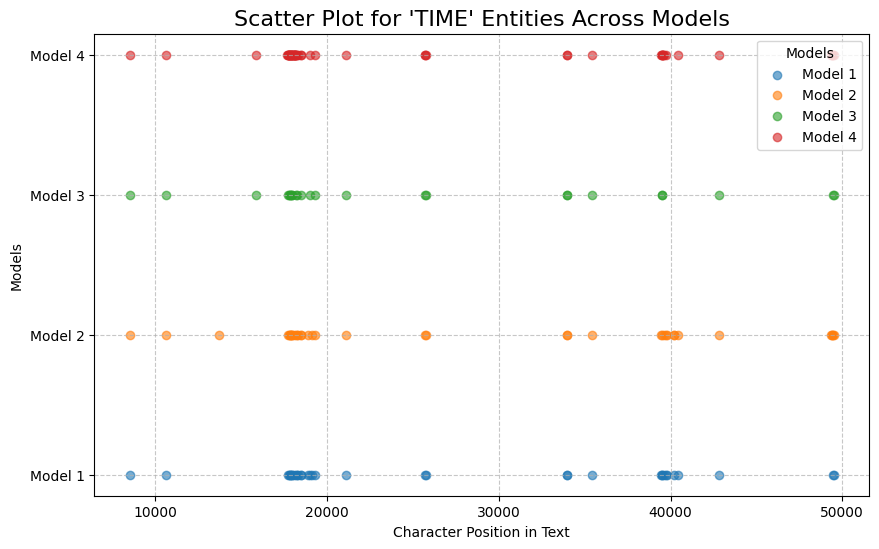

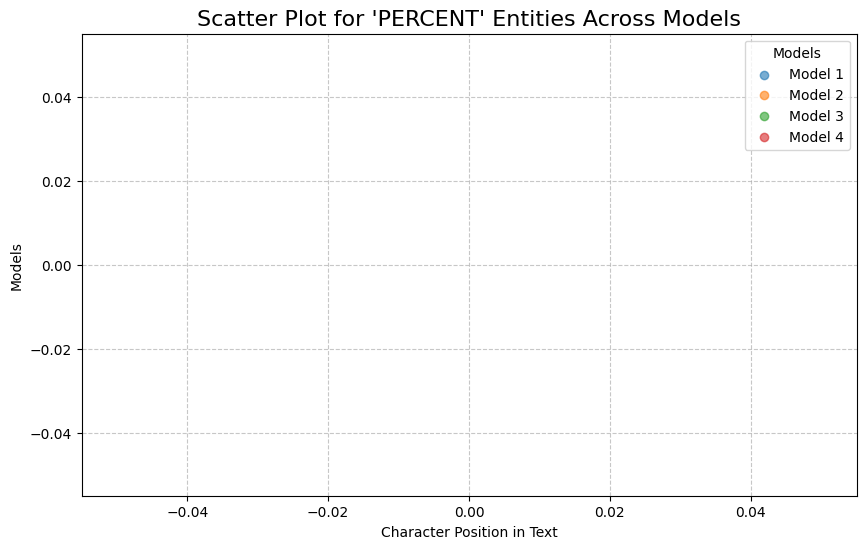

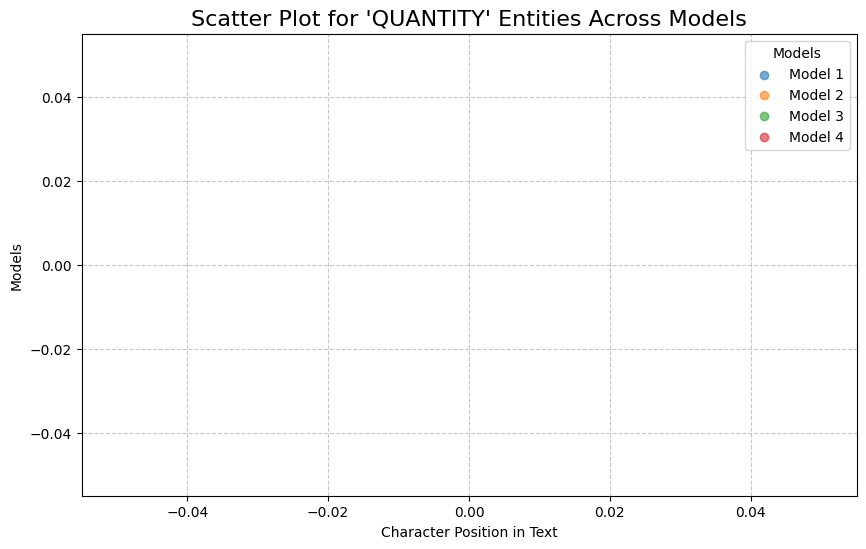

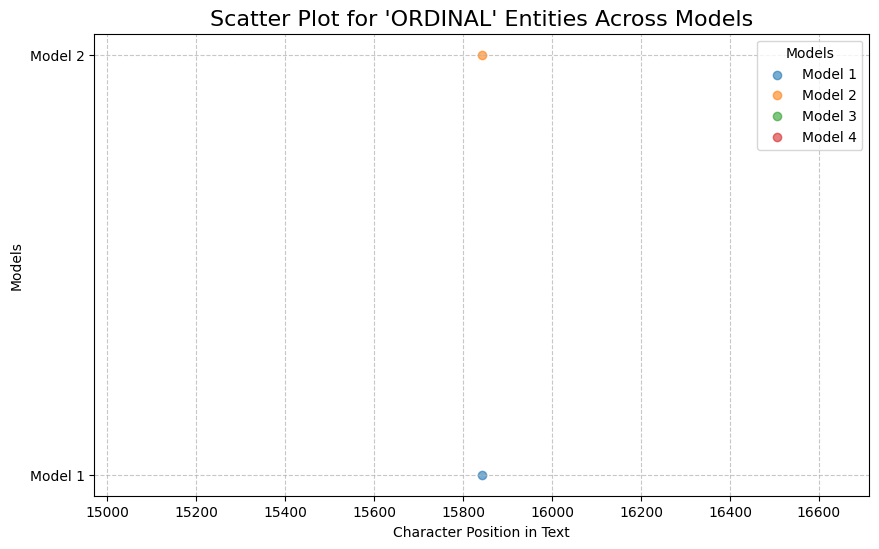

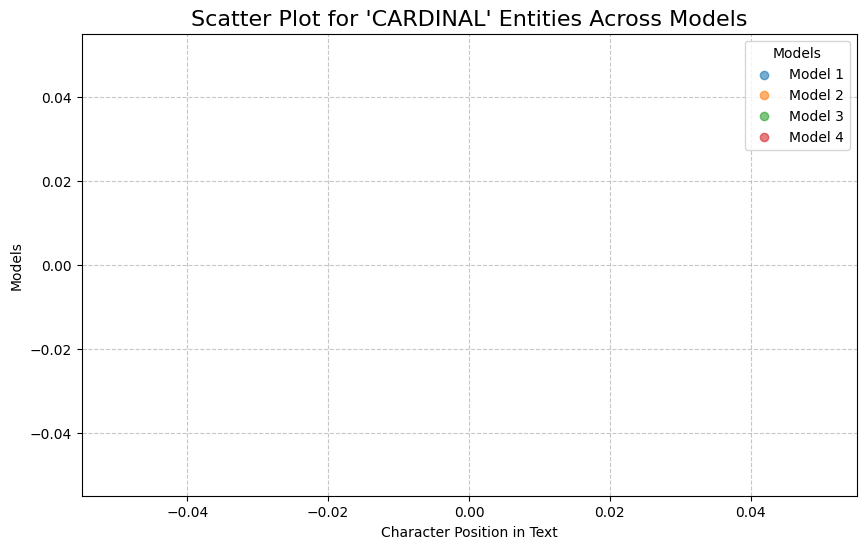

In [39]:
# Initialize dictionary to store entity positions for each model and each entity type
entity_positions = {model_name: {label: [] for label in ["PERSON", "ORG", "DATE", "GPE", "LOC", "NORP", "MONEY", "TIME", "FAC", "PRODUCT","EVENT","WORK_OF_ART","LAW","LANGUAGE","TIME","PERCENT","QUANTITY","ORDINAL","CARDINAL"]}
                    for model_name in model_names}


"""PERSON:      People, including fictional.
NORP:        Nationalities or religious or political groups.
FAC:         Buildings, airports, highways, bridges, etc.
ORG:         Companies, agencies, institutions, etc.
GPE:         Countries, cities, states.
LOC:         Non-GPE locations, mountain ranges, bodies of water.
PRODUCT:     Objects, vehicles, foods, etc. (Not services.)
EVENT:       Named hurricanes, battles, wars, sports events, etc.
WORK_OF_ART: Titles of books, songs, etc.
LAW:         Named documents made into laws.
LANGUAGE:    Any named language.
DATE:        Absolute or relative dates or periods.
TIME:        Times smaller than a day.
PERCENT:     Percentage, including ”%“.
MONEY:       Monetary values, including unit.
QUANTITY:    Measurements, as of weight or distance.
ORDINAL:     “first”, “second”, etc.
CARDINAL:    Numerals that do not fall under another type"""


# Extracting the start and end positions of entities for each model and entity type
for i, model in enumerate(models):
    doc = model(text)
    for entity in doc.ents:
        if entity.label_ in entity_positions[model_names[i]]:
            # Store the start and end position for each entity type
            entity_positions[model_names[i]][entity.label_].append((entity.start_char, entity.end_char))

# Scatter plot for each entity type
for entity_type in ["PERSON", "ORG", "DATE", "GPE", "LOC", "NORP", "MONEY", "TIME", "FAC", "PRODUCT","EVENT","WORK_OF_ART","LAW","LANGUAGE","TIME","PERCENT","QUANTITY","ORDINAL","CARDINAL"]:
    plt.figure(figsize=(10, 6))
    
    for model_name in model_names:
        positions = entity_positions[model_name][entity_type]
        start_positions = [pos[0] for pos in positions]
        plt.scatter(start_positions, [model_name] * len(start_positions), label=model_name, alpha=0.6)
    
    # Adding visual enhancements
    plt.title(f"Scatter Plot for '{entity_type}' Entities Across Models", fontsize=16)
    plt.xlabel("Character Position in Text")
    plt.ylabel("Models")
    plt.legend(title="Models", loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()
